In [1]:
import numpy as np
import matplotlib.pyplot as plt
import classy as cl

# Evolution of $\chi_0$ for different masses

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f', 'chi_0', 'chi_0_prime', 'V_chi', 'dV_chi', 'ddV_chi'])
dict_keys(['scale factor a', 'z', 'conf. time [Mpc]', 'x_e', "kappa' [Mpc^-1]", 'exp(-kappa)', 'g [Mpc^-1]', 'Tb [K]', 'dTb [K]', 'w_b', 'c_b^2', 'kappa_b'])


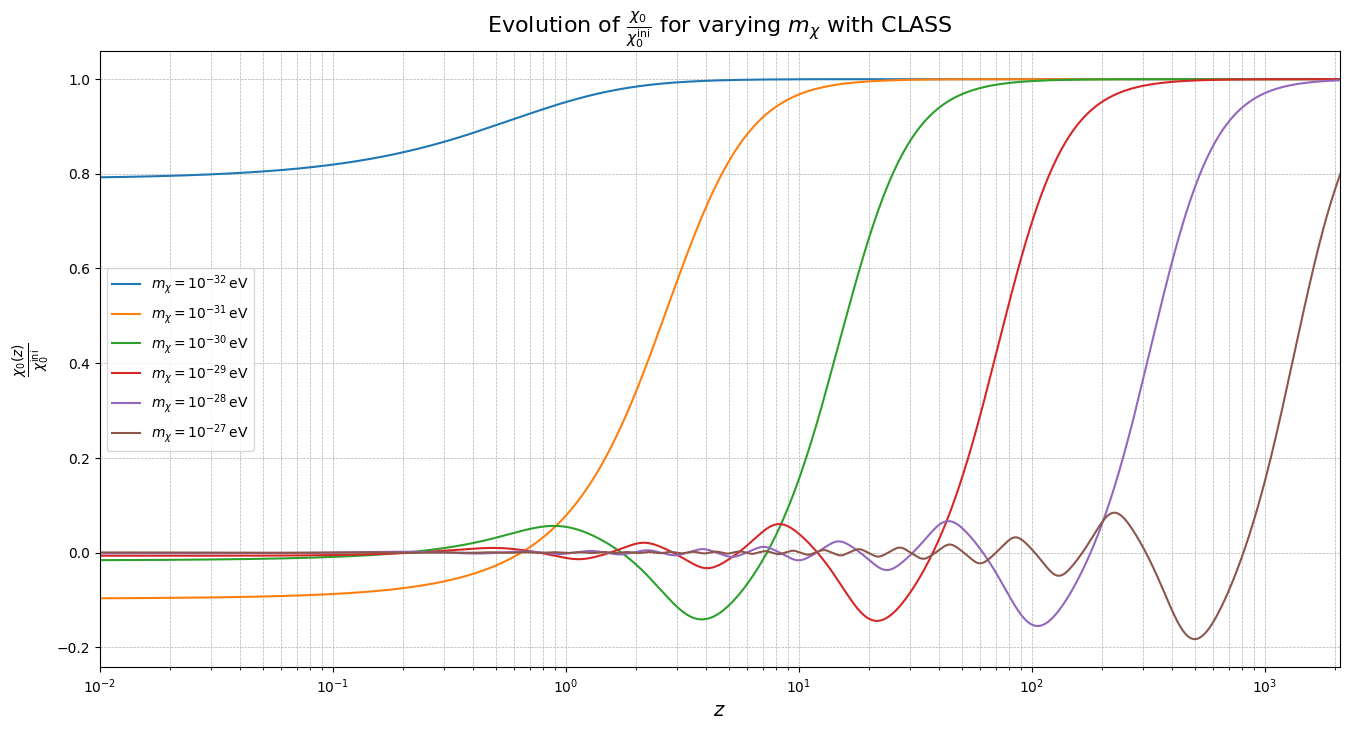

In [2]:
eV_to_Mpc=1.5637e29
mx_values=np.logspace(-32, -27, 6)*eV_to_Mpc
x0_ini=1.0    #In CLASS m_pl=1

def LaTex_mass(mx_values):
    exp = int(np.log10(mx_values/(eV_to_Mpc)))
    return rf'10^{{{exp}}}\,\mathrm{{eV}}'

plt.figure(figsize=(16, 8))
for m in mx_values:
    cosmo=cl.Class()
    cosmo.set({
        'm_chi': m,          
        'chi_ini': x0_ini,
        'chi_prime_ini': 0.0,
        'use_chi': 'yes'
    })
    cosmo.compute(['background'])
    
    bg=cosmo.get_background()
    th=cosmo.get_thermodynamics()
    z = bg['z']
    ratio=bg['chi_0']/x0_ini
    plt.plot(z, ratio, label=rf'$m_\chi={LaTex_mass(m)}$')
    cosmo.struct_cleanup()
    cosmo.empty()

print(bg.keys())
print(th.keys())

plt.xlabel(r'$z$', fontsize=14)
plt.xscale('log')
plt.xlim(1e-2, 2100)
plt.ylabel(r'$\frac{\chi_0(z)}{\chi_0^{\mathrm{ini}}}$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Evolution of $\frac{\chi_0}{\chi_0^{\rm ini}}$ for varying $m_\chi$ with CLASS', fontsize=16)
plt.legend()
plt.show()
plt.show()


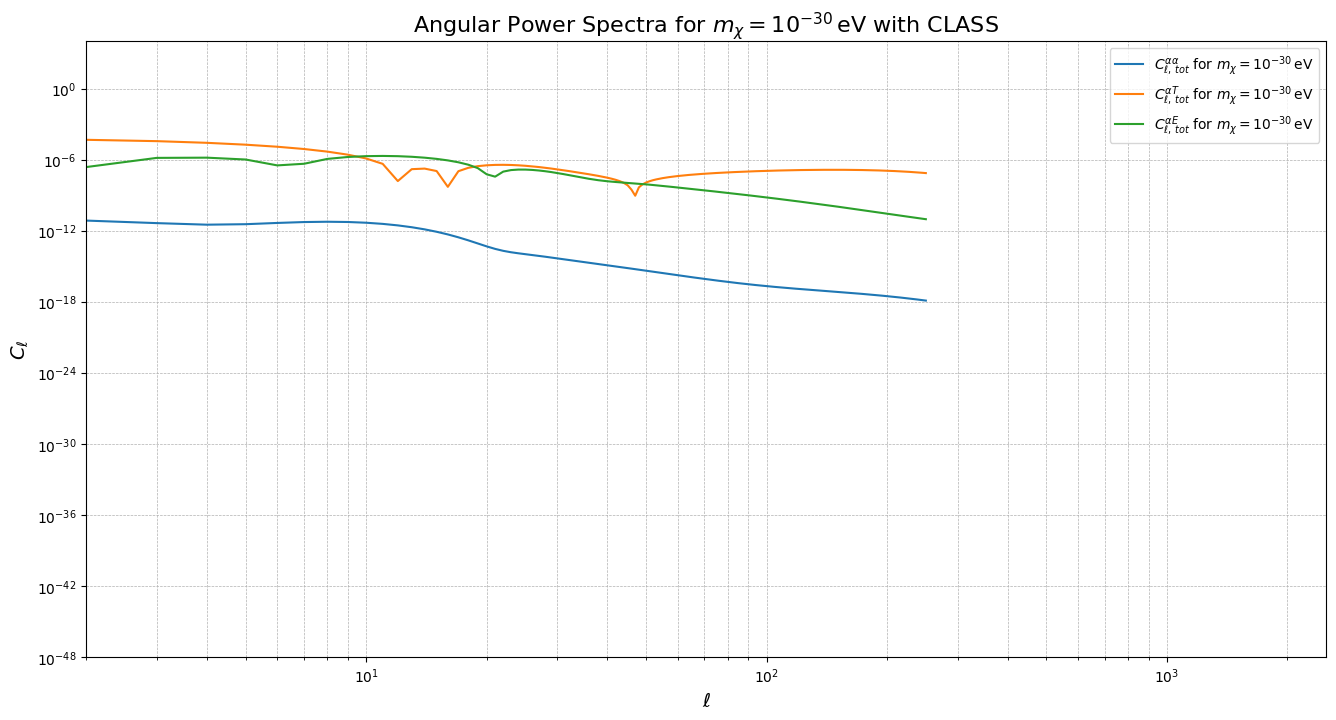

In [3]:
rad_to_deg=180/np.pi
dimless_to_muk=2.7255*1e6

d1 = np.loadtxt("class_public-master/output/m1e-27__cl.dat")
d2 = np.loadtxt("class_public-master/output/m1e-28__cl.dat")
d3 = np.loadtxt("class_public-master/output/m1e-29__cl.dat")
d4 = np.loadtxt("class_public-master/output/m1e-30__cl.dat")
d5 = np.loadtxt("class_public-master/output/m1e-31__cl.dat")
d6 = np.loadtxt("class_public-master/output/m1e-32__cl.dat")

ell = d1[:,0]

claa_tot28 = d2[:, 5] * rad_to_deg**2
claT_tot28 = d2[:, 8] * rad_to_deg * dimless_to_muk
claE_tot28 = d2[:, 10] * rad_to_deg * dimless_to_muk
claa_tot30 = d4[:, 5] * rad_to_deg**2
claT_tot30 = d4[:, 8] * rad_to_deg * dimless_to_muk
claE_tot30 = d4[:, 10] * rad_to_deg * dimless_to_muk
claa_tot32 = d6[:, 5] * rad_to_deg**2
claT_tot32 = d6[:, 8] * rad_to_deg * dimless_to_muk
claE_tot32 = d6[:, 10] * rad_to_deg * dimless_to_muk

plt.figure(figsize=(16, 8))
#plt.plot(ell, claa_tot28, label=r'$C^{\alpha\alpha}_{\ell,\, tot}$ for $m_\chi=10^{- 28}\,\mathrm{eV}$')
#plt.plot(ell, np.abs(claT_tot28), label=r'$C^{\alpha T}_{\ell,\, tot}$ for $m_\chi=10^{- 28}\,\mathrm{eV}$')
#plt.plot(ell, np.abs(claE_tot28), label=r'$C^{\alpha E}_{\ell,\, tot}$ for $m_\chi=10^{- 28}\,\mathrm{eV}$')
plt.plot(ell, claa_tot30, label=r'$C^{\alpha\alpha}_{\ell,\, tot}$ for $m_\chi=10^{- 30}\,\mathrm{eV}$')
plt.plot(ell, np.abs(claT_tot30), label=r'$C^{\alpha T}_{\ell,\, tot}$ for $m_\chi=10^{- 30}\,\mathrm{eV}$')
plt.plot(ell, np.abs(claE_tot30), label=r'$C^{\alpha E}_{\ell,\, tot}$ for $m_\chi=10^{- 30}\,\mathrm{eV}$')
#plt.plot(ell, claa_tot32, label=r'$C^{\alpha\alpha}_{\ell,\, tot}$ for $m_\chi=10^{- 32}\,\mathrm{eV}$')
#plt.plot(ell, np.abs(claT_tot32), label=r'$C^{\alpha T}_{\ell,\, tot}$ for $m_\chi=10^{- 32}\,\mathrm{eV}$')
#plt.plot(ell, np.abs(claE_tot32), label=r'$C^{\alpha E}_{\ell,\, tot}$ for $m_\chi=10^{- 32}\,\mathrm{eV}$')
plt.xlabel(r'$\ell$', fontsize=14)
plt.xscale('log')
plt.xlim(2, 2500)
plt.yscale('log')
plt.ylim(1e-48, 1e4)
plt.ylabel(r'$C_\ell$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Angular Power Spectra for $m_\chi=10^{- 30}\,\mathrm{eV}$ with CLASS', fontsize=16)
plt.legend()
plt.show()


# $C^{\alpha\alpha}_{\ell ,\, reco\times reco}$

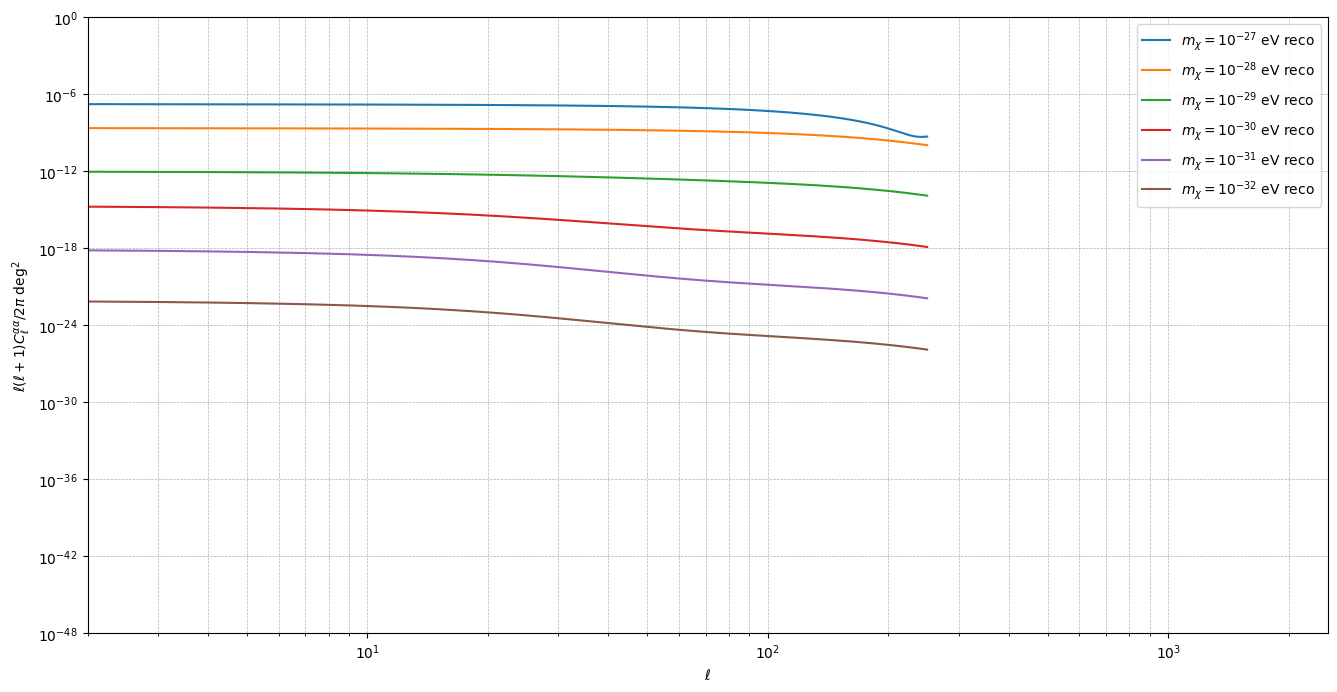

In [4]:
rad_to_deg=180/np.pi
dimless_to_muk=2.7255*1e6

d1 = np.loadtxt("class_public-master/output/m1e-27__cl.dat")
d2 = np.loadtxt("class_public-master/output/m1e-28__cl.dat")
d3 = np.loadtxt("class_public-master/output/m1e-29__cl.dat")
d4 = np.loadtxt("class_public-master/output/m1e-30__cl.dat")
d5 = np.loadtxt("class_public-master/output/m1e-31__cl.dat")
d6 = np.loadtxt("class_public-master/output/m1e-32__cl.dat")

ell = d1[:,0]
claa_reco27  = d1[:,6]*rad_to_deg**2
claa_reco28  = d2[:,6]*rad_to_deg**2
claa_reco29  = d3[:,6]*rad_to_deg**2
claa_reco30  = d4[:,6]*rad_to_deg**2
claa_reco31  = d5[:,6]*rad_to_deg**2
claa_reco32  = d6[:,6]*rad_to_deg**2

 
plt.figure(figsize=(16, 8))
plt.loglog(ell, claa_reco27, label=r"$m_\chi=10^{-27}$ eV reco")
plt.loglog(ell, claa_reco28, label=r"$m_\chi=10^{-28}$ eV reco")
plt.loglog(ell, claa_reco29, label=r"$m_\chi=10^{-29}$ eV reco")
plt.loglog(ell, claa_reco30, label=r"$m_\chi=10^{-30}$ eV reco")
plt.loglog(ell, claa_reco31, label=r"$m_\chi=10^{-31}$ eV reco")
plt.loglog(ell, claa_reco32, label=r"$m_\chi=10^{-32}$ eV reco")
plt.legend(fontsize=10, frameon=True)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)C_\ell^{\alpha\alpha}/2\pi$ $\text{deg}^2$")
plt.ylim(1e-48, 1e0)
plt.xlim(2, 2500)
plt.grid(which='both', linestyle='--', linewidth=0.5, alpha=1)
plt.show()

# $C^{\alpha T}_{\ell ,\, reco\times reco}$

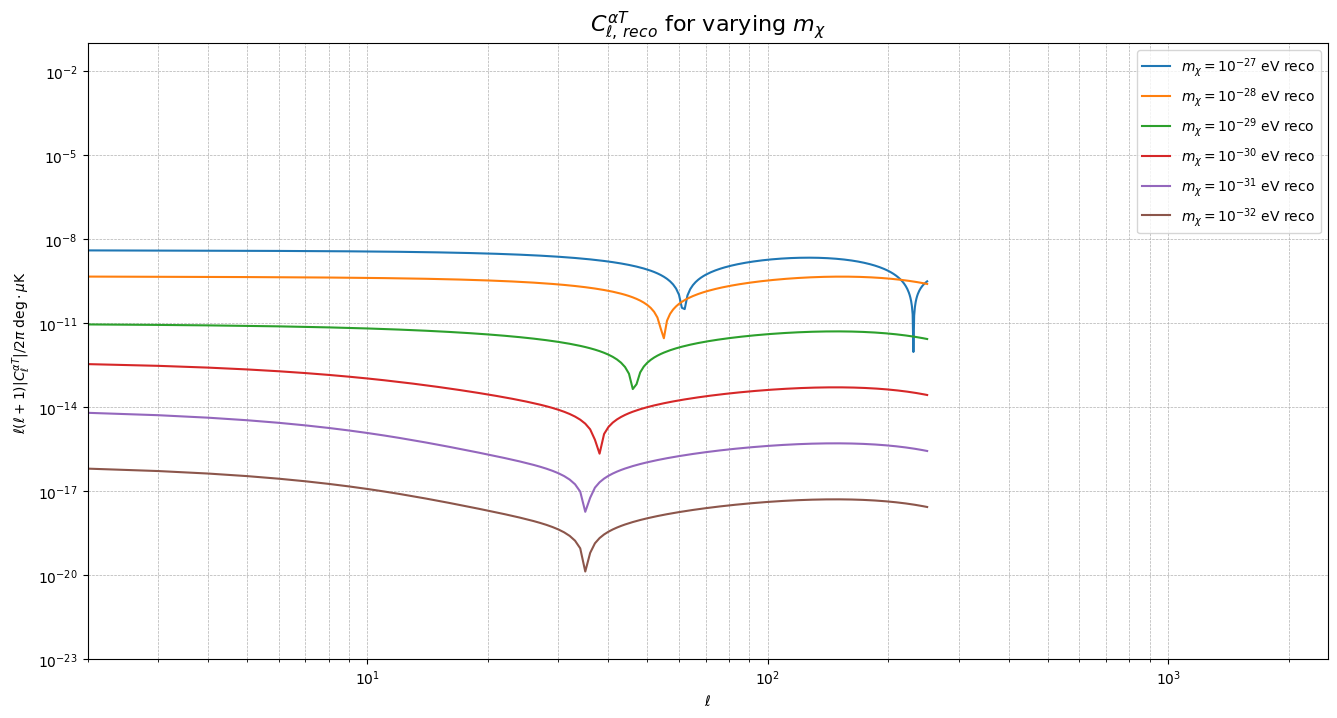

In [5]:
ell = d1[:,0]

claT_reco27 = d1[:,9]*rad_to_deg
claT_reco28  = d2[:,9]*rad_to_deg
claT_reco29 = d3[:,9]*rad_to_deg
claT_reco30  = d4[:,9]*rad_to_deg
claT_reco31 = d5[:,9]*rad_to_deg
claT_reco32  = d6[:,9]*rad_to_deg


 
plt.figure(figsize=(16, 8))
plt.title(r"$C_{\ell ,\, reco} ^{\alpha T}$ for varying $m_\chi$", fontsize=16)
plt.loglog(ell, np.abs(claT_reco27), label=r"$m_\chi=10^{-27}$ eV reco")
plt.loglog(ell, np.abs(claT_reco28), label=r"$m_\chi=10^{-28}$ eV reco")
plt.loglog(ell, np.abs(claT_reco29), label=r"$m_\chi=10^{-29}$ eV reco")
plt.loglog(ell, np.abs(claT_reco30), label=r"$m_\chi=10^{-30}$ eV reco")
plt.loglog(ell, np.abs(claT_reco31), label=r"$m_\chi=10^{-31}$ eV reco")
plt.loglog(ell, np.abs(claT_reco32), label=r"$m_\chi=10^{-32}$ eV reco")

plt.legend(fontsize=10, frameon=True)
plt.xlim(2, 2500)
plt.ylim(1e-23, 1e-1)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)|C_\ell^{\alpha T}|/2\pi$ $\text{deg}\cdot\mu\text{K}$")
plt.grid(which='both', linestyle='--', linewidth=0.5, alpha=1)
plt.legend(fontsize=10, frameon=True)
plt.show()

# $C^{\alpha E}_{\ell ,\, reco\times reco}$

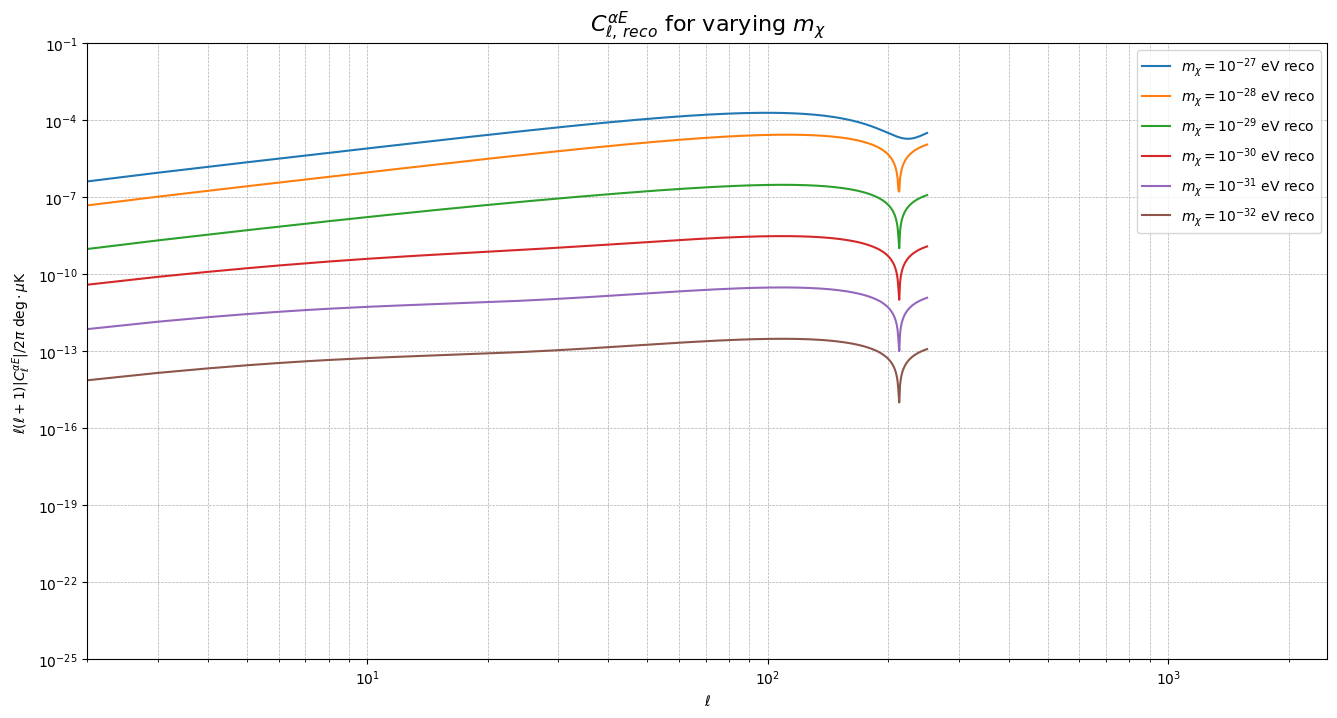

In [6]:
ell = d2[:,0]

claE_reco27 = d1[:,12]*dimless_to_muk*rad_to_deg
claE_reco28  = d2[:,12]*dimless_to_muk*rad_to_deg
claE_reco29 = d3[:,12]*dimless_to_muk*rad_to_deg
claE_reco30  = d4[:,12]*dimless_to_muk*rad_to_deg
claE_reco31 = d5[:,12]*dimless_to_muk*rad_to_deg
claE_reco32  = d6[:,12]*dimless_to_muk*rad_to_deg


 
plt.figure(figsize=(16, 8))
plt.title(r"$C_{\ell ,\, reco} ^{\alpha E}$ for varying $m_\chi$", fontsize=16)
plt.loglog(ell, np.abs(claE_reco27), label=r"$m_\chi=10^{-27}$ eV reco")
plt.loglog(ell, np.abs(claE_reco28), label=r"$m_\chi=10^{-28}$ eV reco")
plt.loglog(ell, np.abs(claE_reco29), label=r"$m_\chi=10^{-29}$ eV reco")
plt.loglog(ell, np.abs(claE_reco30), label=r"$m_\chi=10^{-30}$ eV reco")
plt.loglog(ell, np.abs(claE_reco31), label=r"$m_\chi=10^{-31}$ eV reco")
plt.loglog(ell, np.abs(claE_reco32), label=r"$m_\chi=10^{-32}$ eV reco")

plt.legend(fontsize=10, frameon=True)
plt.xlim(2, 2500)
plt.ylim(1e-25, 1e-1)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)|C_\ell^{\alpha E}|/2\pi$ $\text{deg}\cdot\mu\text{K}$")
plt.grid(which='both', linestyle='--', linewidth=0.5, alpha=1)
plt.legend(fontsize=10, frameon=True)
plt.show()

# $C^{\alpha T}_{\ell ,\, reco\times reco}$ and $C^{\alpha E}_{\ell ,\, reco\times reco}$
Here I tried to plot also the negative contributions using the scale symlog of matplotlib for the $y$ axis.

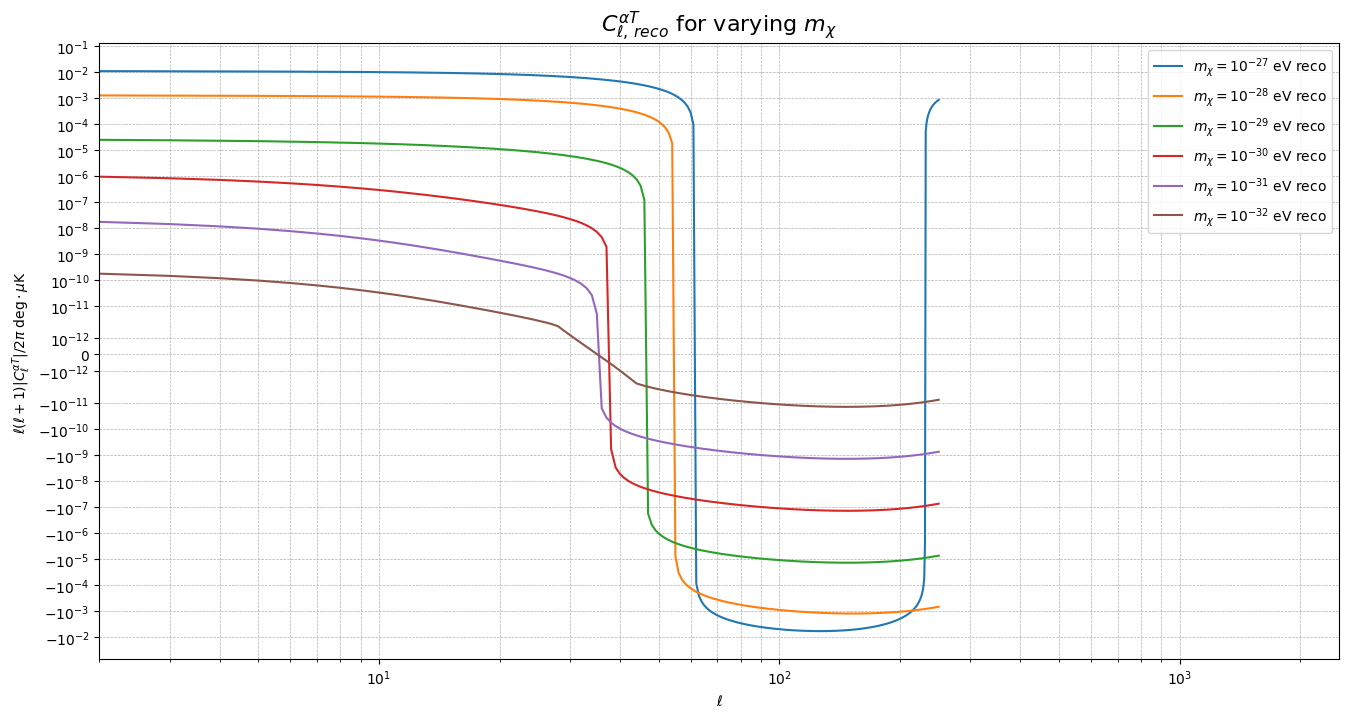

In [7]:
ell = d1[:,0]

claT_reco27 = d1[:,9]*dimless_to_muk*rad_to_deg
claT_reco28  = d2[:,9]*dimless_to_muk*rad_to_deg
claT_reco29 = d3[:,9]*dimless_to_muk*rad_to_deg
claT_reco30  = d4[:,9]*dimless_to_muk*rad_to_deg
claT_reco31 = d5[:,9]*dimless_to_muk*rad_to_deg
claT_reco32  = d6[:,9]*dimless_to_muk*rad_to_deg


 
plt.figure(figsize=(16, 8))
plt.title(r"$C_{\ell ,\, reco} ^{\alpha T}$ for varying $m_\chi$", fontsize=16)
plt.plot(ell, claT_reco27, label=r"$m_\chi=10^{-27}$ eV reco")
plt.plot(ell, claT_reco28, label=r"$m_\chi=10^{-28}$ eV reco")
plt.plot(ell, claT_reco29, label=r"$m_\chi=10^{-29}$ eV reco")
plt.plot(ell, claT_reco30, label=r"$m_\chi=10^{-30}$ eV reco")
plt.plot(ell, claT_reco31, label=r"$m_\chi=10^{-31}$ eV reco")
plt.plot(ell, claT_reco32, label=r"$m_\chi=10^{-32}$ eV reco")
ymax = np.nanmax(np.abs(claT_reco32))
linthresh = ymax * 1e-2
plt.yscale('symlog', linthresh=linthresh)
plt.xscale('log')
plt.legend(fontsize=10, frameon=True)
plt.xlim(2, 2500)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)|C_\ell^{\alpha T}|/2\pi$ $\text{deg}\cdot\mu\text{K}$")
plt.grid(which='both', linestyle='--', linewidth=0.5, alpha=1)
plt.legend(fontsize=10, frameon=True)
plt.show()

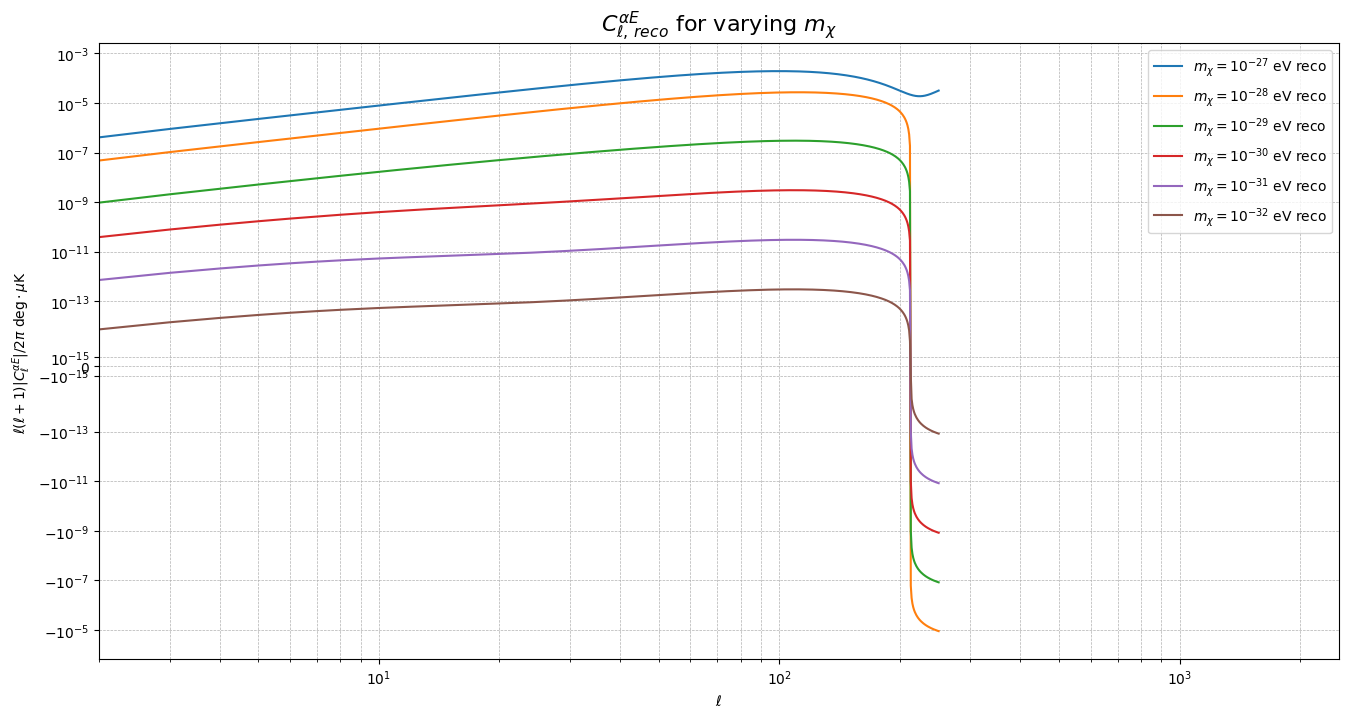

In [8]:
ell = d2[:,0]

claE_reco27 = d1[:,12]*dimless_to_muk*rad_to_deg
claE_reco28  = d2[:,12]*dimless_to_muk*rad_to_deg
claE_reco29 = d3[:,12]*dimless_to_muk*rad_to_deg
claE_reco30  = d4[:,12]*dimless_to_muk*rad_to_deg
claE_reco31 = d5[:,12]*dimless_to_muk*rad_to_deg
claE_reco32  = d6[:,12]*dimless_to_muk*rad_to_deg


 
plt.figure(figsize=(16, 8))
plt.title(r"$C_{\ell ,\, reco} ^{\alpha E}$ for varying $m_\chi$", fontsize=16)
plt.plot(ell, claE_reco27, label=r"$m_\chi=10^{-27}$ eV reco")
plt.plot(ell, claE_reco28, label=r"$m_\chi=10^{-28}$ eV reco")
plt.plot(ell, claE_reco29, label=r"$m_\chi=10^{-29}$ eV reco")
plt.plot(ell, claE_reco30, label=r"$m_\chi=10^{-30}$ eV reco")
plt.plot(ell, claE_reco31, label=r"$m_\chi=10^{-31}$ eV reco")
plt.plot(ell, claE_reco32, label=r"$m_\chi=10^{-32}$ eV reco")
ymax = np.nanmax(np.abs(claE_reco32))
linthresh = ymax * 1e-2
plt.yscale('symlog', linthresh=linthresh)
plt.xscale('log')
plt.legend(fontsize=10, frameon=True)
plt.xlim(2, 2500)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)|C_\ell^{\alpha E}|/2\pi$ $\text{deg}\cdot\mu\text{K}$")
plt.grid(which='both', linestyle='--', linewidth=0.5, alpha=1)
plt.legend(fontsize=10, frameon=True)
plt.show()

# $C^{\alpha \alpha}_{\ell ,\, reio\times reio}$, $C^{\alpha T}_{\ell ,\, reio\times reio}$ and $C^{\alpha E}_{\ell ,\, reio\times reio}$
Here is where everything kind of breaks down. This part is the most sensitive to the window function chosen.

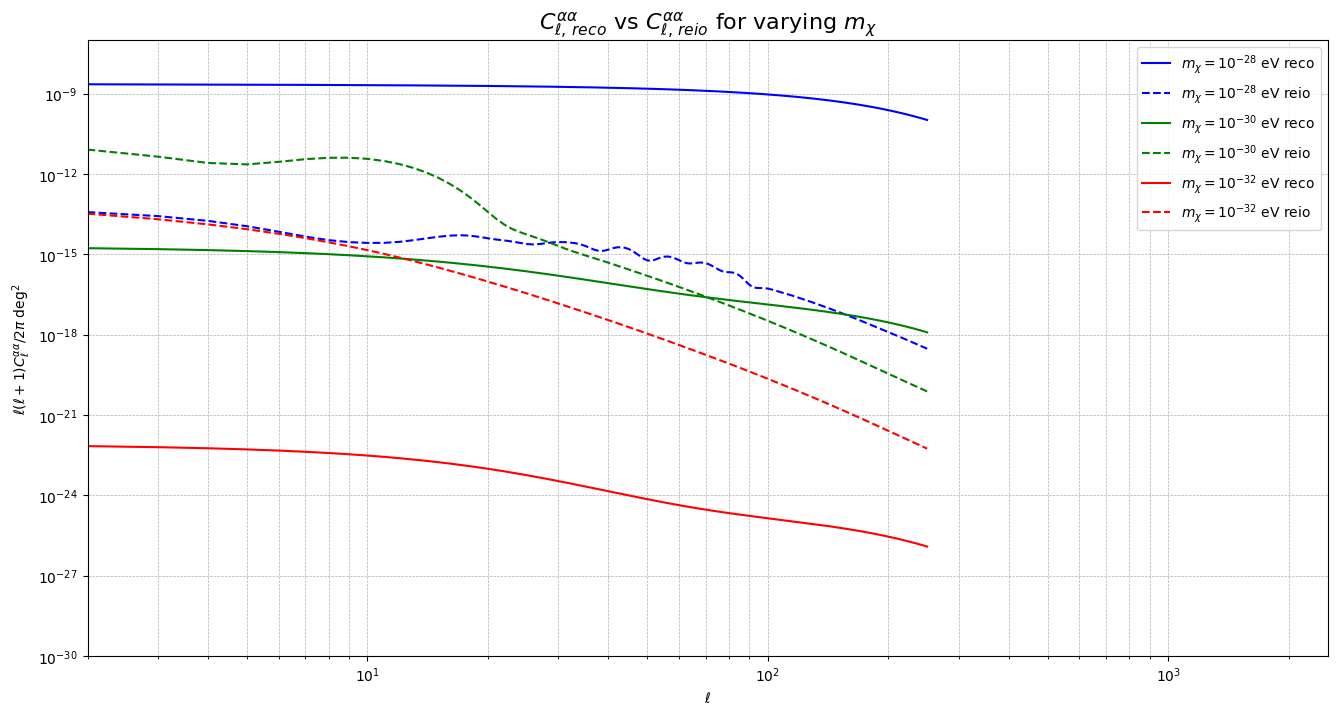

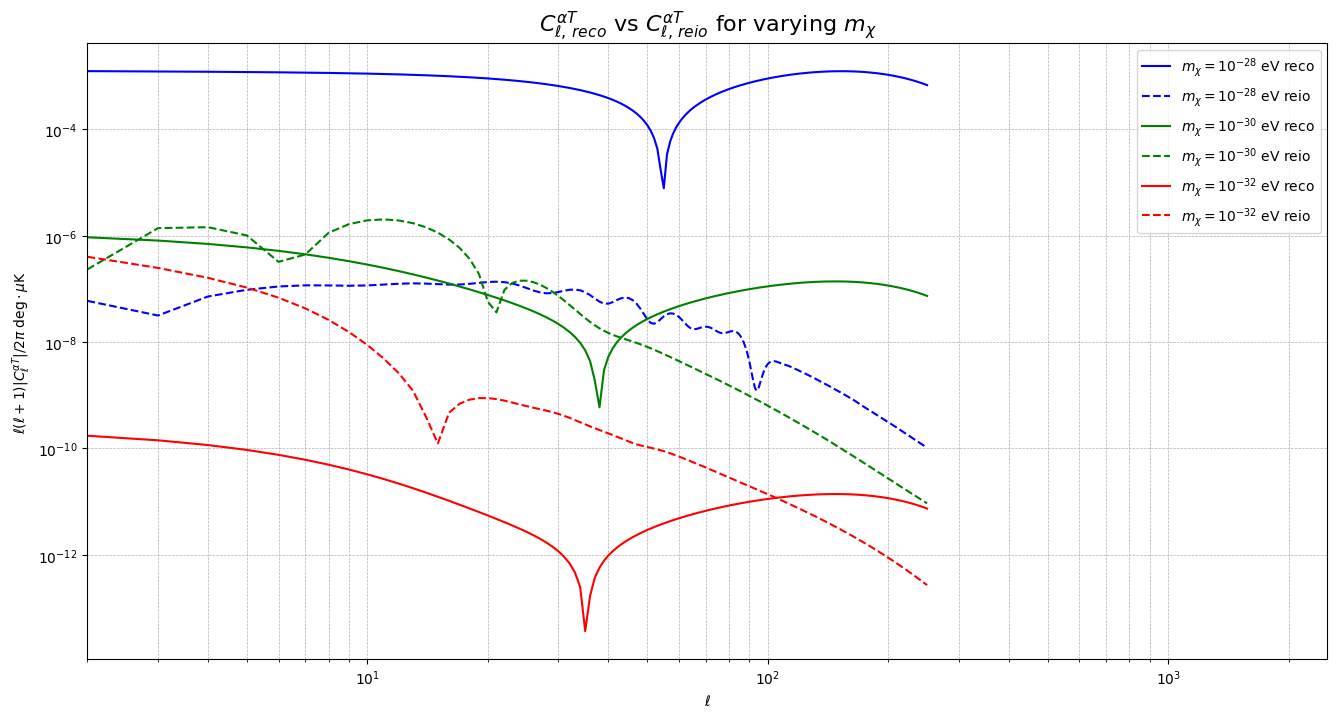

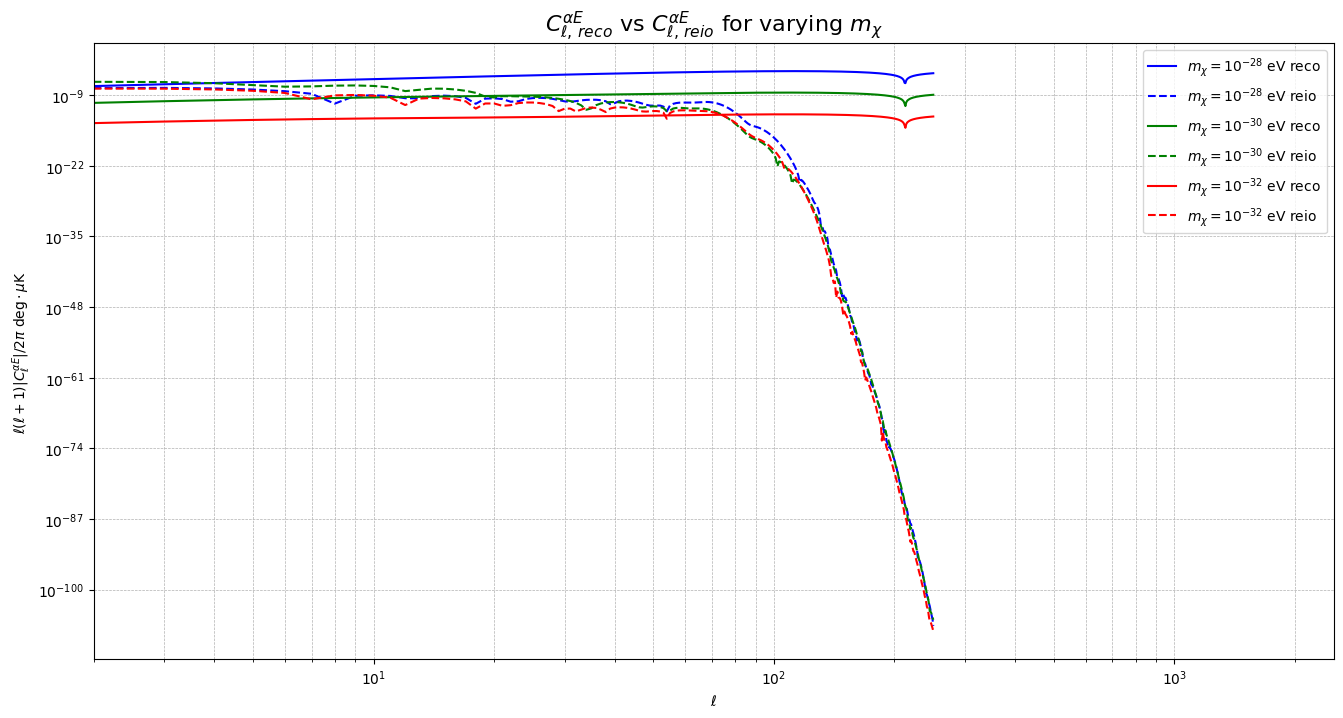

In [9]:
claa_reio28 = d2[:,7]*rad_to_deg**2
claa_reio30 = d4[:,7]*rad_to_deg**2
claa_reio32 = d6[:,7]*rad_to_deg**2

claT_reio28 = d2[:,10]*dimless_to_muk*rad_to_deg
claT_reio30 = d4[:,10]*dimless_to_muk*rad_to_deg
claT_reio32 = d6[:,10]*dimless_to_muk*rad_to_deg

claE_reio28 = d2[:,13]*dimless_to_muk*rad_to_deg
claE_reio30 = d4[:,13]*dimless_to_muk*rad_to_deg
claE_reio32 = d6[:,13]*dimless_to_muk*rad_to_deg


plt.figure(figsize=(16, 8))
plt.title(r"$C_{\ell ,\, reco} ^{\alpha\alpha}$ vs $C_{\ell ,\, reio} ^{\alpha\alpha}$ for varying $m_\chi$", fontsize=16)
plt.loglog(ell, claa_reco28, color='b',label=r"$m_\chi=10^{-28}$ eV reco")
plt.loglog(ell, claa_reio28,linestyle='--',color='b',label=r"$m_\chi=10^{-28}$ eV reio")
plt.loglog(ell, claa_reco30, color='g', label=r"$m_\chi=10^{-30}$ eV reco")
plt.loglog(ell, claa_reio30, linestyle='--',color='g',label=r"$m_\chi=10^{-30}$ eV reio")
plt.loglog(ell, claa_reco32, color='r', label=r"$m_\chi=10^{-32}$ eV reco")
plt.loglog(ell, claa_reio32, linestyle='--',color='r',label=r"$m_\chi=10^{-32}$ eV reio")
plt.legend(fontsize=10, frameon=True)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)C_\ell^{\alpha\alpha}/2\pi$ $\text{deg}^2$")
plt.ylim(1e-30, 1e-7)
plt.xlim(2, 2500)
plt.grid(which='both', linestyle='--', linewidth=0.5, alpha=1)
plt.show()


plt.figure(figsize=(16, 8))
plt.title(r"$C_{\ell ,\, reco} ^{\alpha T}$ vs $C_{\ell ,\, reio} ^{\alpha T}$ for varying $m_\chi$", fontsize=16)
plt.loglog(ell, np.abs(claT_reco28), color='b',label=r"$m_\chi=10^{-28}$ eV reco")
plt.loglog(ell, np.abs(claT_reio28),linestyle='--',color='b',label=r"$m_\chi=10^{-28}$ eV reio")
plt.loglog(ell, np.abs(claT_reco30), color='g', label=r"$m_\chi=10^{-30}$ eV reco")
plt.loglog(ell, np.abs(claT_reio30), linestyle='--',color='g',label=r"$m_\chi=10^{-30}$ eV reio")
plt.loglog(ell, np.abs(claT_reco32), color='r', label=r"$m_\chi=10^{-32}$ eV reco")
plt.loglog(ell, np.abs(claT_reio32), linestyle='--',color='r',label=r"$m_\chi=10^{-32}$ eV reio")
plt.legend(fontsize=10, frameon=True)
plt.xlim(2, 2500)
#plt.ylim(1e-25, 1e-1)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)|C_\ell^{\alpha T}|/2\pi$ $\text{deg}\cdot\mu\text{K}$")
plt.grid(which='both', linestyle='--', linewidth=0.5, alpha=1)
plt.legend(fontsize=10, frameon=True)
plt.show()


plt.figure(figsize=(16, 8))
plt.title(r"$C_{\ell ,\, reco} ^{\alpha E}$ vs $C_{\ell ,\, reio} ^{\alpha E}$ for varying $m_\chi$", fontsize=16)
plt.loglog(ell, np.abs(claE_reco28), color='b',label=r"$m_\chi=10^{-28}$ eV reco")
plt.loglog(ell, np.abs(claE_reio28),linestyle='--',color='b',label=r"$m_\chi=10^{-28}$ eV reio")
plt.loglog(ell, np.abs(claE_reco30), color='g', label=r"$m_\chi=10^{-30}$ eV reco")
plt.loglog(ell, np.abs(claE_reio30), linestyle='--',color='g',label=r"$m_\chi=10^{-30}$ eV reio")
plt.loglog(ell, np.abs(claE_reco32), color='r', label=r"$m_\chi=10^{-32}$ eV reco")
plt.loglog(ell, np.abs(claE_reio32), linestyle='--',color='r',label=r"$m_\chi=10^{-32}$ eV reio")
plt.legend(fontsize=10, frameon=True)
plt.xlim(2, 2500)
#plt.ylim(1e-25, 1e-1)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)|C_\ell^{\alpha E}|/2\pi$ $\text{deg}\cdot\mu\text{K}$")
plt.grid(which='both', linestyle='--', linewidth=0.5, alpha=1)
plt.legend(fontsize=10, frameon=True)
plt.show()

# Unrotated spectra

# Exact rotation

# Rotated spectra


In [10]:
import sympy as sp
for m in mx_values:
    cosmo = cl.Class()
    cosmo.set({
        "output": "tCl,pCl,lCl",
        "l_max_scalars": 250,
    })
    cosmo.compute()

    rot = cosmo.rotation_cl_inputs(250)
    print(rot["alpha0_reco"], rot["alpha0_reio"])

def I(ell, L1, L2, s1, s2, s3):
    prefactor = (2 * ell +1) * (2 * L1 +1) * (2 * L2 +1) / (4 * np.pi)
    w3j = sp.physics.wigner.wigner3j(ell, L1, L2, -s1, -s2, -s3)
    return prefactor * float(w3j)

def V_alpha(ells, Cl_aa):
    total = 0.0
    for ell in ells:
        total += (2 * ell + 1) / (4 * np.pi) * Cl_aa[ell]
    return total

def Cl_EE_rot(ells, Cl_EE, Cl_BB, Cl_aa, Cl_aE, alpha_0, V_alpha):
    Cl_EE_rot = np.zeros_like(ells, dtype=float)

    for ell in ells:
        Cl_EE_prefactor = (1 - 4*V_alpha) * (Cl_EE[ell] * np.cos(2*alpha_0)**2 + Cl_BB[ell] * np.sin(2*alpha_0)**2)

        sum = 0.0
        for L1 in ells:
            for L2 in ells:
                I1 = (ell, L1, L2, 2, -2, 0)
                I2 = (ell, L1, L2, 2, 0, -2)

                parity = (-1)**(ell + L1 + L2)

                auto = ( Cl_EE[L1] * (1.0 - parity * np.cos(4.0 * alpha_0)) + Cl_BB[L1] * (1.0 + parity * np.cos(4.0 * alpha_0)) ) * Cl_aa[L2]
                cross = I2 * Cl_EE[L1] * ( 1.0 - parity * np.cos(4.0 * alpha_0) ) * Cl_aE[L2]

                sum += I1 * ( I1 * auto + cross)
        
        rotation = (2.0 / (2.0 * ell + 1.0)) * sum

        Cl_EE_rot[ell] = Cl_EE_prefactor + rotation
    
    return Cl_EE_rot

ells = np.arange(2, 251)




0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
